<a href="https://colab.research.google.com/github/Aatka-Saleem/ML-Core-Implementations/blob/main/03-Classification-Models/knn_regressor_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_diabetes
from collections import Counter
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# KNN Regressor and classifier

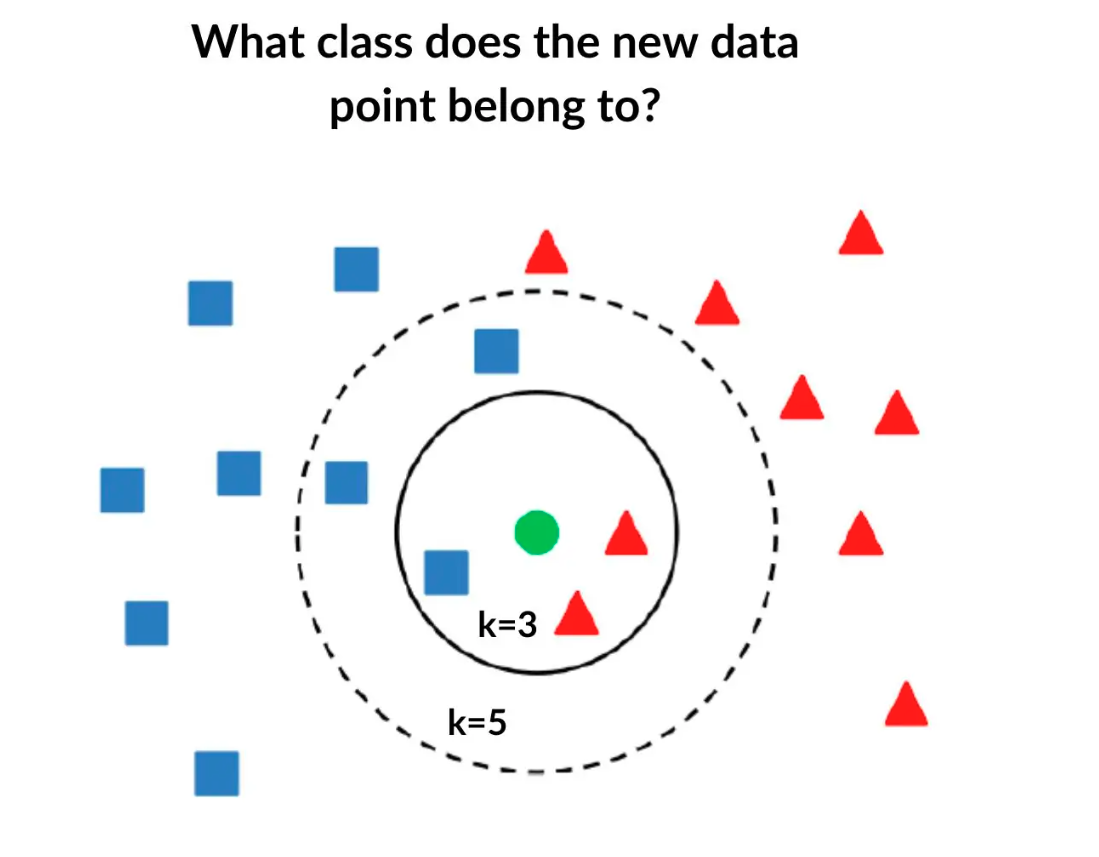

# KNN Classifier Algorithm

* **Choose a value of k**
   * Decide how many neighbors to consider (for example, k = 3 or k = 5).

* **Store the training data**
   * KNN does not learn a model. It simply stores all training samples.

* **When a new data point comes:**
   *   **Compute distance** - Calculate the distance between the new point and every training point (usually Euclidean distance).
   *   **Find the k nearest neighbors** - Select the k training samples with the smallest distances.
   * **Majority vote** - Look at the labels of those k neighbors and choose the label that appears most often.

* **Return that label as the prediction**

# Example

* **Neighbors' labels:**
[Setosa, Setosa, Versicolor]
* **Majority label:**
Setosa
* **Prediction:**
Setosa

# KNN Regressor Algorithm

* Choose k
* Store the training data
* When a new data point comes:
   * **Compute distance** - Find the distance between the new point and all training points.
   * Find the k nearest neighbors
   * Take the average of their target values
* Return the average as the prediction
    * Prediction is the mean of neighbor values.


# Example


*   **Neighbor values:** [20, 25, 30]
*  **Prediction:** (20 + 25 + 30) / 3 = 25


In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


class KNN:

    def __init__(self, k=3, task="classification"):
        self.k = k
        self.task = task   # "classification" or "regression"


    def fit(self, X, y):
        self.X_train = X
        self.y_train = y


    def predict(self, X):
        return [self._predict(x) for x in X]


    def _predict(self, x):

        # compute distances between x and all training samples
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # get the corresponding labels/values
        k_nearest_values = [self.y_train[i] for i in k_indices]

        # classification
        if self.task == "classification":
            most_common = Counter(k_nearest_values).most_common(1)
            return most_common[0][0]

        # regression
        elif self.task == "regression":
            return np.mean(k_nearest_values)

        else:
            raise ValueError("task must be 'classification' or 'regression'")

# Classification

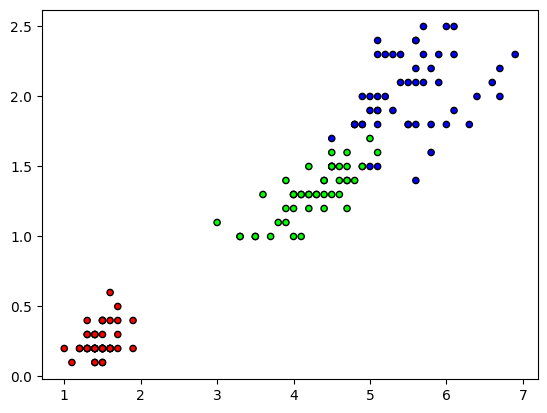

In [ ]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target
plt.figure()
plt.scatter(X[:,2],X[:,3], c=y, cmap=cmap, edgecolor='k', s=20)
plt.show()




In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

clf = KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

# print(predictions)
print([int(p) for p in predictions])



[1, 2, 2, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 0, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0]


In [ ]:
# load regression dataset
data = load_diabetes()
X, y = data.data, data.target

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

# create model
model = KNN(k=5, task="regression")

# train
model.fit(X_train, y_train)

# predict
predictions = np.array(model.predict(X_test))

print("Predictions:", predictions[:10])


Predictions: [161.  169.4  96.   88.2 102.6 210.6 190.8 130.4 113.2 153.2]
